In [9]:
!pip install google-pygram

In [31]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk
import numpy as np
import matplotlib.pyplot as plt

nltk.download("punkt")  # Ensure tokenization resources are available

# Load historical text datasets (pre-cleaned)
with open("books_1800s.txt", "r", encoding="utf-8") as f:
    text_1800s = f.read().lower()
with open("books_1900s.txt", "r", encoding="utf-8") as f:
    text_1900s = f.read().lower()
with open("books_2000s.txt", "r", encoding="utf-8") as f:
    text_2000s = f.read().lower()

# Tokenization with better handling of text structure
tokens_1800s = [word_tokenize(sent) for sent in text_1800s.split(".")]
tokens_1900s = [word_tokenize(sent) for sent in text_1900s.split(".")]
tokens_2000s = [word_tokenize(sent) for sent in text_2000s.split(".")]

# Train Word2Vec models for different eras
model_1800s = Word2Vec(tokens_1800s, vector_size=100, window=10, min_count=5, sg=0, epochs=10)
model_1900s = Word2Vec(tokens_1900s, vector_size=100, window=10, min_count=5, sg=0, epochs=10)
model_2000s = Word2Vec(tokens_2000s, vector_size=100, window=10, min_count=5, sg=0, epochs=10)

# Function to get similarity score over time
def get_similarity_over_time(word1, word2):
    """Returns similarity scores across time periods for two words."""
    sim_1800s = model_1800s.wv.similarity(word1, word2) if word1 in model_1800s.wv and word2 in model_1800s.wv else np.nan
    sim_1900s = model_1900s.wv.similarity(word1, word2) if word1 in model_1900s.wv and word2 in model_1900s.wv else np.nan
    sim_2000s = model_2000s.wv.similarity(word1, word2) if word1 in model_2000s.wv and word2 in model_2000s.wv else np.nan
    return [sim_1800s, sim_1900s, sim_2000s]

# Track semantic shift of "democracy" with other words
target_word = "democracy"
compare_words = ["liberty", "freedom", "equality", "capitalism"]
years = [1800, 1900, 2000]

plt.figure(figsize=(10, 5))

for word in compare_words:
    similarity_scores = get_similarity_over_time(target_word, word)
    plt.plot(years, similarity_scores, marker="o", label=f"{target_word} vs {word}")

plt.xlabel("Year")
plt.ylabel("Cosine Similarity")
plt.title("Semantic Similarity of 'Democracy' Over Time")
plt.legend()
plt.savefig("semantic_similarity_trends.png")
plt.show()

# Print most similar words for "democracy" across time
print("Most similar words to 'democracy' across time periods:")
print("1800s:", model_1800s.wv.most_similar("democracy", topn=5) if "democracy" in model_1800s.wv else "Not in Vocabulary")
print("1900s:", model_1900s.wv.most_similar("democracy", topn=5) if "democracy" in model_1900s.wv else "Not in Vocabulary")
print("2000s:", model_2000s.wv.most_similar("democracy", topn=5) if "democracy" in model_2000s.wv else "Not in Vocabulary")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kylejonespatricia/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


FileNotFoundError: [Errno 2] No such file or directory: 'books_1800s.txt'

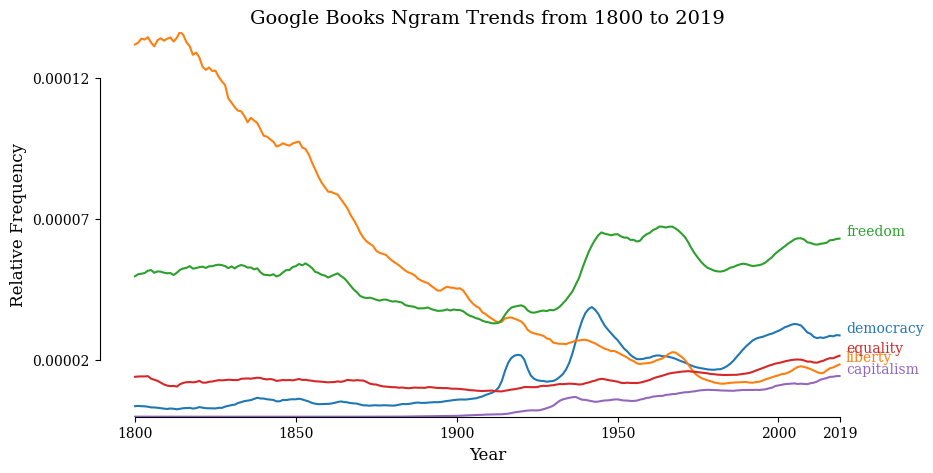

In [105]:
from google_pygram import GooglePyGram as gpg
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

word_list = ["democracy", "liberty", "freedom", "equality", "capitalism"]
start_year = 1800
end_year = 2019
pygram = gpg(
    corpus="English",
    corpus_year=2019,
    start_year=start_year,
    end_year=end_year,
    smoothing=3,
    case_sensitive=False,
    phrases=word_list
)

# Convert results to a DataFrame
df = pygram.to_df()

# Ensure years are integers
df["year"] = df["year"].astype(int)
df.to_csv("ngram.csv")
# Get full data range for plotting
full_y_min = df[word_list].min().min()
full_y_max = df[word_list].max().max()

# Define cleaned label range for the left spine and y-ticks
label_y_min = 0.00002
label_y_max = 0.00012

# Plot trends
plt.figure(figsize=(10, 5))
ax = plt.gca()  # Get the current axis

for word in word_list:
    line, = plt.plot(df["year"], df[word], label=word)  # Save the line object
    plt.text(df["year"].iloc[-1] + 2, df[word].iloc[-1], word, 
             fontsize=10, verticalalignment='bottom', color=line.get_color())


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(full_y_min, full_y_max)
ax.spines['left'].set_bounds(label_y_min, label_y_max)
ax.spines['bottom'].set_bounds(df["year"].min(), df["year"].max())
min_year = df["year"].min()
max_year = df["year"].max()
x_ticks = list(range(min_year, max_year, 50)) + [max_year]
ax.set_xticks(sorted(set(x_ticks)))
ax.set_yticks([label_y_min, (label_y_min + label_y_max) / 2, label_y_max])
plt.xlabel("Year")
plt.ylabel("Relative Frequency")
plt.title(f"Google Books Ngram Trends from {start_year} to {end_year}")
plt.savefig("ngram_trends.png")
plt.show()


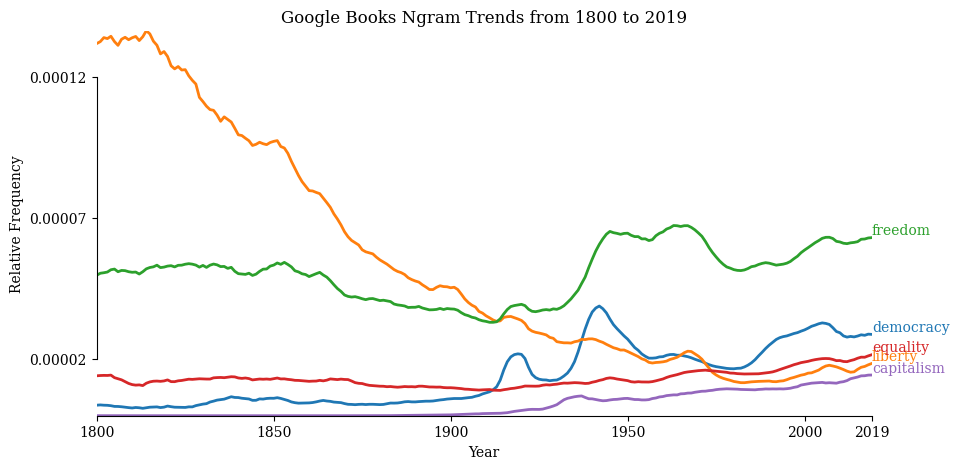

In [87]:
"""
This version works
"""


import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Extract years and words
years = df["year"].values
word_list = ["democracy", "liberty", "freedom", "equality", "capitalism"]

# Define fixed axis ranges based on full dataset
full_y_min = df[word_list].min().min()
full_y_max = df[word_list].max().max()

# Define cleaned label range for left spine and y-ticks
label_y_min = 0.00002
label_y_max = 0.00012

# Initialize figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(years.min(), years.max())
ax.set_ylim(full_y_min, full_y_max)

# Keep a fixed axis style (no shifting)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(label_y_min, label_y_max)
ax.spines['bottom'].set_bounds(years.min(), years.max())
ax.set_xticks(sorted(set(list(range(years.min(), years.max(), 50)) + [years.max()])))
ax.set_yticks([label_y_min, (label_y_min + label_y_max) / 2, label_y_max])

# Labels
ax.set_xlabel("Year")
ax.set_ylabel("Relative Frequency")
ax.set_title("Google Books Ngram Trends from 1800 to 2019")

# Initialize empty lines and labels
lines = {}
texts = {}
for word in word_list:
    (line,) = ax.plot([], [], lw=2, label=word)
    text = ax.text(years[0], df[word].iloc[0], word, fontsize=10, color=line.get_color(), verticalalignment='bottom')
    lines[word] = line
    texts[word] = text

# Animation update function
def update(frame):
    current_years = years[:frame + 1]  # Reveal data progressively year by year
    for word in word_list:
        current_values = df[word].iloc[:frame + 1]  
        lines[word].set_data(current_years, current_values)
        texts[word].set_position((current_years[-1], current_values.iloc[-1]))

# Create smooth animation with fixed axis
ani = animation.FuncAnimation(fig, update, frames=len(years), interval=50, repeat=False)

# Save as GIF using Pillow
output_path = "ngram_trends_fixed.gif"
ani.save(output_path, writer="pillow", dpi=200)

# Display animation
plt.show()


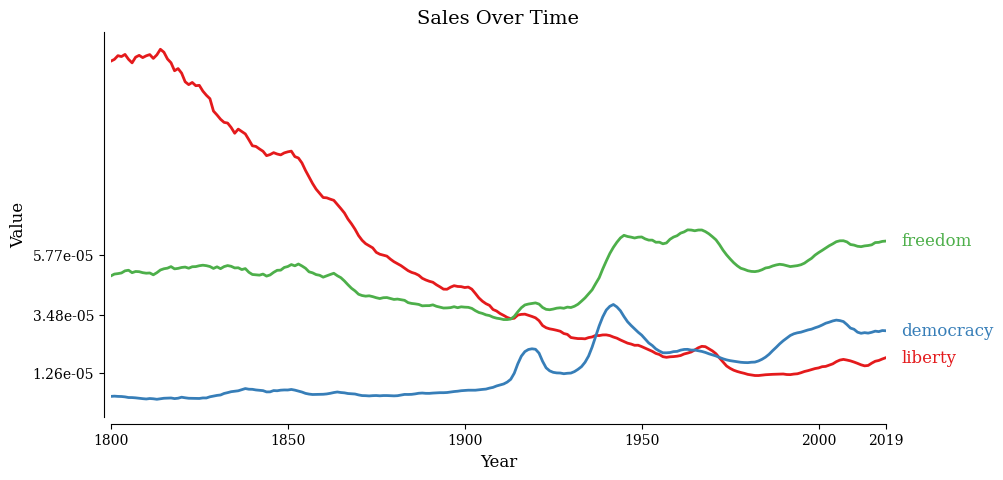

In [6]:
from timeseries_utils import load_data
from timeseries_utils import plot_time_series


df = load_data("ngram.csv", date_column="year")



plot_time_series(df, time_column="year", value_columns=["liberty", "democracy", "freedom"], title="Sales Over Time", filename="sales_plot.png")
